In [10]:
import pandas as pd

df = pd.read_csv("data/311.csv", low_memory=False)

print(df.shape)
df.head()

(37454, 44)


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,67394822,01/05/2026 12:56:50 PM,01/05/2026 06:14:32 PM,DSNY,Department of Sanitation,Dirty Condition,Trash,Littering,Sidewalk,10035.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"40,80477867844","-73,93631454667",POINT (-73.936314546671 40.804778678441)
1,67392104,01/05/2026 12:56:50 PM,01/05/2026 01:59:20 PM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,NaN,Street/Sidewalk,11205.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"40,69455537614","-73,95424867767",POINT (-73.954248677671 40.694555376137)
2,67396909,01/05/2026 12:56:45 PM,01/05/2026 02:34:15 PM,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,NaN,Residential Building/House,11225.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"40,66515315607","-73,95373536849",POINT (-73.953735368493 40.665153156065)
3,67401119,01/05/2026 12:56:42 PM,01/05/2026 02:00:16 PM,NYPD,New York City Police Department,Illegal Parking,License Plate Obscured,NaN,Street/Sidewalk,11220.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"40,64285233866","-74,01109835873",POINT (-74.01109835873 40.642852338658)
4,67400477,01/05/2026 12:56:41 PM,01/07/2026 03:45:33 PM,HPD,Department of Housing Preservation and Develop...,PAINT/PLASTER,WALL,BULGING/HOLE/CRACKED,RESIDENTIAL BUILDING,10473.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"40,81886061038","-73,86720805133",POINT (-73.867208051329 40.818860610378)


In [12]:
import pandas as pd

# Asegurar formato fecha
df["Created Date"] = pd.to_datetime(df["Created Date"], errors="coerce")
df["Closed Date"] = pd.to_datetime(df["Closed Date"], errors="coerce")

# Crear columna tiempo de resolución en horas
df["resolution_hours"] = (
    (df["Closed Date"] - df["Created Date"])
    .dt.total_seconds() / 3600
)

# Ver estadísticas básicas
print("Total requests:", len(df))
print("Average resolution time (hours):", df["resolution_hours"].mean())
print("\nTop Complaint Types:")
df["Problem (formerly Complaint Type)"].value_counts().head(10)

C:\Users\Ferrer\AppData\Local\Temp\ipykernel_5580\1747289440.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Closed Date"] = pd.to_datetime(df["Closed Date"], errors="coerce")


Total requests: 37454
Average resolution time (hours): 83.075946971494

Top Complaint Types:


Problem (formerly Complaint Type)
HEAT/HOT WATER             9428
Illegal Parking            5706
Noise - Residential        3714
Blocked Driveway           1882
UNSANITARY CONDITION       1244
PLUMBING                    906
Water System                708
PAINT/PLASTER               655
Noise - Street/Sidewalk     612
Dirty Condition             583
Name: count, dtype: int64

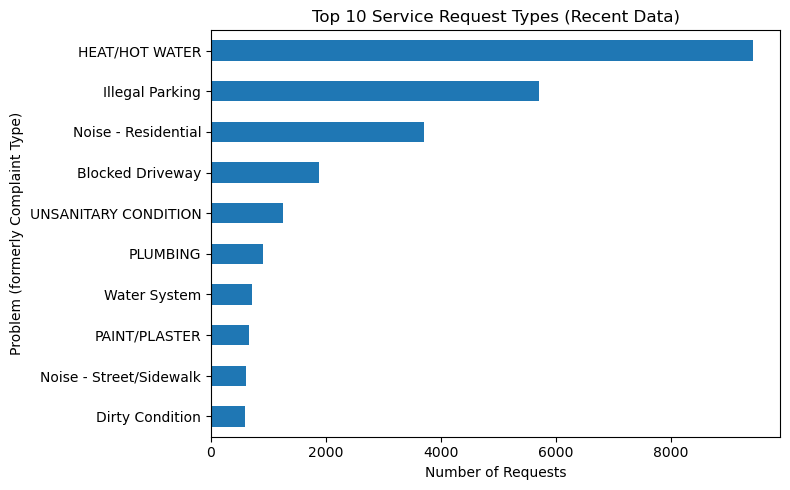

In [14]:
import matplotlib.pyplot as plt

top_problems = df["Problem (formerly Complaint Type)"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_problems.sort_values().plot(kind='barh')
plt.title("Top 10 Service Request Types (Recent Data)")
plt.xlabel("Number of Requests")
plt.tight_layout()
plt.show()

In [13]:
print("\nRequests by Borough:")
print(df["Borough"].value_counts())

print("\nAverage resolution time by Borough:")
print(df.groupby("Borough")["resolution_hours"].mean())


Requests by Borough:
Borough
BROOKLYN         11333
BRONX             8565
QUEENS            8293
MANHATTAN         8137
STATEN ISLAND     1097
Unspecified         29
Name: count, dtype: int64

Average resolution time by Borough:
Borough
BRONX             92.680958
BROOKLYN          83.718489
MANHATTAN         96.657584
QUEENS            61.838986
STATEN ISLAND     65.037454
Unspecified      191.502526
Name: resolution_hours, dtype: float64


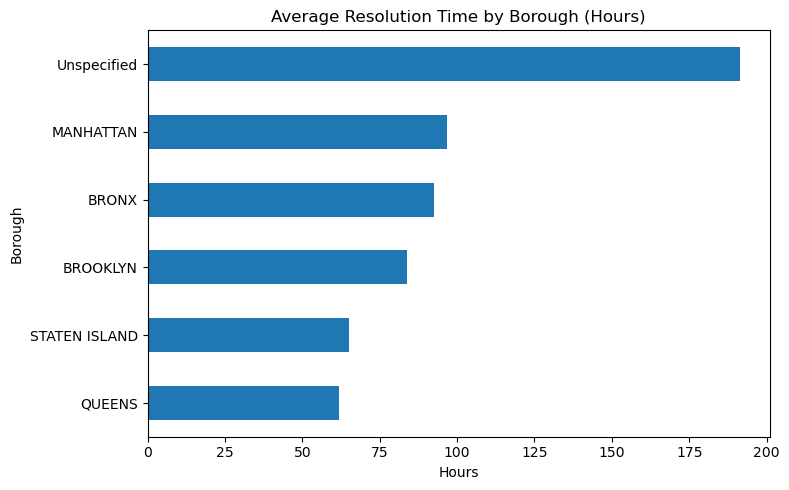

In [16]:
import matplotlib.pyplot as plt

avg_resolution = df.groupby("Borough")["resolution_hours"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_resolution.plot(kind="barh")
plt.title("Average Resolution Time by Borough (Hours)")
plt.xlabel("Hours")
plt.tight_layout()
plt.show()

In [4]:
import os
from openai import OpenAI

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

print("API ready")

In [6]:
!pip install openai

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ------- -------------------------------- 0.2/1.1 MB 6.9 MB/s eta 0:00:01
   ---------------- ----------------------- 0.5/1.1 MB 5.9 MB/s eta 0:00:01
   ------------------------ --------------- 0.7/1.1 MB 5.6 MB/s eta 0:00:01
   ---------------------------------- ----- 1.0/1.1 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------  1.1/1.1 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 5.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/205.4 kB ? eta -:--:--
   ---------------------------------------  204.8/205.4 kB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 205.4/205.4 kB 4.2 MB/s eta 0:00:00


In [20]:
import os
from openai import OpenAI

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

print("API ready")

API ready


In [24]:
summary_data = f"""
Total requests: {len(df)}

Average resolution time (hours): {df["resolution_hours"].mean():.2f}

Top problem types:
{df["Problem (formerly Complaint Type)"].value_counts().head(5).to_string()}

Requests by borough:
{df["Borough"].value_counts().to_string()}

Average resolution time by borough:
{df.groupby("Borough")["resolution_hours"].mean().round(2).to_string()}
"""

In [26]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a civic data analyst."},
        {"role": "user", "content": f"""
Based on the following NYC 311 data summary:

{summary_data}

Provide:
1. Executive summary
2. Key patterns
3. Potential operational risks
4. Actionable recommendations for city management

Keep it concise and professional.
"""}
    ],
    max_tokens=400
)

print(response.choices[0].message.content)

### Executive Summary

The recent analysis of NYC 311 data reveals a total of 37,454 service requests, with an overarching average resolution time of 83.08 hours. The data highlights significant issues related to heat and hot water, illegal parking, and residential noise, with Brooklyn being the borough with the highest request volume. While certain boroughs, notably the Bronx and Manhattan, experience longer resolution times, Queens and Staten Island report comparatively quicker resolutions. This analysis underscores critical trends in citizen concerns and operational responsiveness.

### Key Patterns

- **Dominant Complaint Types**: The most prevalent requests pertain to heat/hot water (9,428), illegal parking (5,706), and noise disturbances (3,714), indicating recurrent quality-of-life issues that necessitate targeted interventions.
- **Borough Request Distribution**: Brooklyn leads with 11,333 requests, followed by the Bronx (8,565) and Queens (8,293). Staten Island shows markedly 

In [28]:
response_citizen = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a civic communication specialist."},
        {"role": "user", "content": f"""
Based on the following NYC 311 data summary:

{summary_data}

Write a short citizen-friendly explanation (max 150 words) 
explaining what this means for residents.
Avoid technical jargon.
Focus on quality of life and service improvements.
"""}
    ],
    max_tokens=250
)

print(response_citizen.choices[0].message.content)

In New York City, residents reported a total of 37,454 issues, with the most common problems being heat and hot water complaints, illegal parking, and noise disturbances. On average, it took about 83 hours to resolve these issues. Each borough experiences different challenges; Brooklyn had the highest number of reports, while Staten Island had the fewest. 

Resolution times also varied across boroughs, with the Bronx and Manhattan taking the longest to address concerns. This data highlights where we need to improve services to enhance the quality of life for all residents. By focusing on these common issues and aiming for faster resolutions, we can work together to create a more comfortable and welcoming city for everyone. Your voice matters, and each report helps us identify how to better serve our communities.


In [30]:
!pip install streamlit plotly